# Figure 5a-b



In [ ]:
# Cell 1 -- Imports
import sys
import matplotlib as mpl                  # cell 1 imports pyplot, not mpl itself
from matplotlib import colormaps
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial.transform import Rotation
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add 3d_tracking_dataset root to path for utils
_nb_dir = Path().resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import utils.io_dict_to_hdf5 as ioh5

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10

In [31]:
# Cell 2 -- Configuration
FPS = 800  # Hz

# Combined bout-dict HDF5 (grooming, session 6) -- UPDATE PATH AS NEEDED
H5_PATH = Path('/home/user/3D_tracking_paper/grooming/Predictions_3D_20260602-094148/v1_groom/ik_output_combined_v1_groom_free_running.h5')
OUTPUT_DIR = Path('/home/user/3D_tracking_paper/figure_5')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Front legs only
FRONT_LEGS = ['T1_left', 'T1_right']
LEG_LABELS = {'T1_left': 'L1 (front-left)', 'T1_right': 'R1 (front-right)'}

T1_JOINTS_FULL = ['coxa_abduct', 'coxa_twist', 'coxa', 'femur_twist', 'femur', 'tibia',
                  'tarsus', 'tarsus2', 'tarsus3', 'tarsus4', 'tarsus5']
JOINT_LABELS = {
    'coxa_abduct': 'Coxa Abd', 'coxa_twist': 'Coxa Rot', 'coxa': 'Coxa Flex',
    'femur_twist': 'Femur Rot', 'femur': 'Femur Flex', 'tibia': 'Tibia Flex',
    'tarsus': 'Tarsus Flex', 'tarsus2': 'Tarsus2', 'tarsus3': 'Tarsus3',
    'tarsus4': 'Tarsus4', 'tarsus5': 'Tarsus5',
}

# Front leg -> raw-keypoint tip name (kp_data / kp_names)
TIP_KP_NAME   = {'T1_left': 'T1L_TaTip', 'T1_right': 'T1R_TaTip'}
# Front leg -> model claw body name (xpos / names_xpos)
CLAW_XPOS_NAME = {'T1_left': 'claw_T1_left', 'T1_right': 'claw_T1_right'}

print(f"Frame rate: {FPS} Hz | Front legs: {FRONT_LEGS}")
print(f"Joint set 'full': {len(T1_JOINTS_FULL)} joints/leg")
print(f"H5 path: {H5_PATH}")
print(f"Output:  {OUTPUT_DIR.absolute()}")

Frame rate: 800 Hz | Front legs: ['T1_left', 'T1_right']
Joint set 'full': 11 joints/leg
H5 path: /home/user/3D_tracking_paper/grooming/Predictions_3D_20260602-094148/v1_groom/ik_output_combined_v1_groom_free_running.h5
Output:  /home/user/3D_tracking_paper/figure_5


In [32]:
# Cell 3 -- Load data and resolve indices
def load_ik_bouts(h5_path):
    """Load bout-dict HDF5 via io_dict_to_hdf5.load()."""
    d = ioh5.load(h5_path)
    bout_keys = sorted(k for k in d if k.startswith('bout_'))
    fly_ids = np.array(d['info']['fly_ids'])
    clip_lengths = np.array(d['info']['clip_lengths'])
    print(f"Loaded {len(bout_keys)} bouts | {len(np.unique(fly_ids))} unique source(s)")
    print(f"Frames/bout: min={clip_lengths.min()}, max={clip_lengths.max()}, "
          f"total={clip_lengths.sum():,}")
    return d, bout_keys, fly_ids, clip_lengths


bout_dict, bout_keys, fly_ids, clip_lengths = load_ik_bouts(H5_PATH)

names_qpos = list(bout_dict['info']['names_qpos'])
names_xpos = list(bout_dict['info']['names_xpos'])
kp_names   = list(bout_dict['info']['kp_names'])

# Front-leg joint indices in qpos: {leg: [(joint, qpos_idx), ...]}
t1_joint_idx = {}
for leg in FRONT_LEGS:
    idxs = []
    for j in T1_JOINTS_FULL:
        full = f"{j}_{leg}"
        if full in names_qpos:
            idxs.append((j, names_qpos.index(full)))
        else:
            print(f"Warning: joint '{full}' not in names_qpos")
    t1_joint_idx[leg] = idxs

CLAW_XPOS   = {leg: names_xpos.index(CLAW_XPOS_NAME[leg]) for leg in FRONT_LEGS}
TIP_KP      = {leg: kp_names.index(TIP_KP_NAME[leg])      for leg in FRONT_LEGS}
HEAD_BODY   = names_xpos.index('head')
THORAX_BODY = names_xpos.index('thorax')

print("claw xpos idx :", CLAW_XPOS)
print("tip  kp  idx  :", TIP_KP)
print("head body idx :", HEAD_BODY, "| thorax body idx:", THORAX_BODY)
for leg in FRONT_LEGS:
    print(f"{leg} qpos joint idx:", [i for _, i in t1_joint_idx[leg]])


def get_bout(key):
    """Return (qpos, xpos, xquat, kp) for a bout. kp reshaped to (T, 50, 3)."""
    b = bout_dict[key]
    qpos  = np.asarray(b['qpos'])
    xpos  = np.asarray(b['xpos'])
    xquat = np.asarray(b['xquat'])
    kp    = np.asarray(b['kp_data']).reshape(qpos.shape[0], -1, 3)
    return qpos, xpos, xquat, kp

Loaded 15 bouts | 1 unique source(s)
Frames/bout: min=196, max=2337, total=16,646
claw xpos idx : {'T1_left': 27, 'T1_right': 35}
tip  kp  idx  : {'T1_left': 18, 'T1_right': 25}
head body idx : 2 | thorax body idx: 1
T1_left qpos joint idx: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
T1_right qpos joint idx: [41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


## Features from measured keypoints


In [ ]:
### Cell G1 -- Grooming vs standing
#

# Body frame, built from THORAX-FIXED keypoints so it cannot rotate with the head:
#     x_hat   Scutellum -> midpoint(T1L_ThxCx, T1R_ThxCx)          anterior
#     y_hat   WingR_base -> WingL_base, orthogonalised to x_hat    left
#     z_hat   x_hat x y_hat                                        dorsal
# Head frame, from Antenna_Base + EyeL + EyeR; head pitch/yaw/roll are that frame
# expressed in the body frame. Tarsus tips are the six *_TaTip keypoints in the body
# frame, in mm.
#
# Standing frames come from the running h5

STANDING_H5      = Path('/mnt/lemebel/running_data/v1/ik_output_combined_v1_free_running.h5')

# The grooming recording is ALSO one of the 53 flies in the running h5, so this fly's own
# standing posture is available -- that is the within-animal control, and it is the
# comparison G4 draws.
GROOM_FLY        = 'session6/2025_10_12_15_06_46'
STAND_MAX_SPEED  = 5.0      # mm/s, thorax XY -- the same gate the walking analysis uses
STAND_MIN_FRAMES = 40       # >= 50 ms of continuous immobility
KP_SMOOTH        = 3        # frames

from scipy.ndimage import gaussian_filter1d   # not in Cell 1's imports

LEGS_6 = ['T1L', 'T1R', 'T2L', 'T2R', 'T3L', 'T3R']
LEG_LAB = {'T1L': 'L1', 'T1R': 'R1', 'T2L': 'L2', 'T2R': 'R2', 'T3L': 'L3', 'T3R': 'R3'}


def _nrm(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.divide(v, n, out=np.full_like(v, np.nan), where=n > 1e-9)


def keypoint_features(K, kpi):
    """K: (T, 50, 3) keypoints in mm. kpi: {name -> column}. -> DataFrame of features."""
    sc  = K[:, kpi['Scutellum']]
    cx  = (K[:, kpi['T1L_ThxCx']] + K[:, kpi['T1R_ThxCx']]) / 2
    xh  = _nrm(cx - sc)
    yr  = K[:, kpi['WingL_base']] - K[:, kpi['WingR_base']]
    yh  = _nrm(yr - np.sum(yr * xh, 1, keepdims=True) * xh)
    zh  = np.cross(xh, yh)
    eye = (K[:, kpi['EyeL']] + K[:, kpi['EyeR']]) / 2
    hy  = _nrm(K[:, kpi['EyeL']] - K[:, kpi['EyeR']])
    hxr = K[:, kpi['Antenna_Base']] - eye
    hx  = _nrm(hxr - np.sum(hxr * hy, 1, keepdims=True) * hy)
    hz  = np.cross(hx, hy)
    dot = lambda a, b: np.sum(a * b, 1)
    out = {
        'head_pitch': np.degrees(-np.arcsin(np.clip(dot(hx, zh), -1, 1))),
        'head_yaw':   np.degrees(np.arctan2(dot(hx, yh), dot(hx, xh))),
        'head_roll':  np.degrees(np.arctan2(dot(hy, zh), dot(hz, zh))),
    }
    for lg in LEGS_6:
        v = K[:, kpi[f'{lg}_TaTip']] - sc
        out[f'{lg}_x'], out[f'{lg}_y'], out[f'{lg}_z'] = dot(v, xh), dot(v, yh), dot(v, zh)
    return pd.DataFrame(out)


# ---- grooming: straight from the already-loaded bout_dict --------------------
# bout_002 is dropped: its projected keypoints are clipped at the Cam2012631 image edge
# (crop 254x314 at x0=0, the narrowest of the 15), so the fly is partly out of frame and
# the 3-D is poorly constrained -- the leg positions are visibly wrong in the video. It
# did NOT flag on a body-frame outlier test, so this exclusion is by inspection.
# Nothing is deleted from the h5; this is a filter, so it is reversible.
EXCLUDE_BOUTS = {'bout_002'}

_kpi = {n: i for i, n in enumerate(kp_names)}
_g = []
for _k in [b for b in bout_keys if b not in EXCLUDE_BOUTS]:
    _K = np.asarray(bout_dict[_k]['kp_data'], dtype=float)
    _K = _K.reshape(_K.shape[0], -1, 3) * 10.0                    # model units -> mm
    _df = keypoint_features(gaussian_filter1d(_K, KP_SMOOTH, axis=0), _kpi)
    _df['bout'] = _k; _df['fly'] = 'grooming fly'; _df['cond'] = 'grooming'
    _g.append(_df)
groom_feat = pd.concat(_g, ignore_index=True)

# ---- standing: immobile stretches from the ORIGINAL running h5 --------------
_s = []
with h5py.File(STANDING_H5, 'r') as _f:
    _kp_r = [_f['info']['kp_names'][k][()].decode()
             for k in sorted(_f['info']['kp_names'], key=int)]
    assert _kp_r == list(kp_names), 'kp_names differ between the two files'
    _nx_r = [_f['info']['names_xpos'][k][()].decode()
             for k in sorted(_f['info']['names_xpos'], key=int)]
    _ti = _nx_r.index('thorax')
    _fid = _f['info']['fly_ids']
    _flies = [_fid[k][()].decode() for k in sorted(_fid, key=int)]
    for _bi, _b in enumerate(tqdm(sorted(k for k in _f if k.startswith('bout_')),
                                  desc='standing bouts')):
        _thx = _f[_b]['xpos'][:, _ti, :2].astype(float) * 10.0
        _spd = np.linalg.norm(np.gradient(gaussian_filter1d(_thx, 2, axis=0), axis=0)
                              * FPS, axis=1)
        _m = np.isfinite(_spd) & (_spd < STAND_MAX_SPEED)
        _d = np.diff(np.concatenate([[0], _m.view(np.int8), [0]]))
        _runs = [(a, z) for a, z in zip(np.flatnonzero(_d == 1), np.flatnonzero(_d == -1))
                 if z - a >= STAND_MIN_FRAMES]
        if not _runs:
            continue
        _K = np.asarray(_f[_b]['kp_data'][()], dtype=float)
        _K = _K.reshape(_K.shape[0], -1, 3) * 10.0
        _K = gaussian_filter1d(_K, KP_SMOOTH, axis=0)
        for _a, _z in _runs:
            _df = keypoint_features(_K[_a:_z], _kpi)
            _df['bout'] = _b; _df['fly'] = _flies[_bi]; _df['cond'] = 'standing'
            _df['unit'] = f'{_b}_r{_a}'          # one quiescent run = one unit of analysis
            _s.append(_df)
stand_feat = pd.concat(_s, ignore_index=True)

print(f'grooming: {len(groom_feat):>7,} frames | {groom_feat.bout.nunique():>4} bouts | '
      f'{groom_feat.fly.nunique()} fly  (excluded: {sorted(EXCLUDE_BOUTS)})')
groom_feat['unit'] = groom_feat['bout']       # one grooming bout = one unit
print(f'standing: {len(stand_feat):>7,} frames | {stand_feat.bout.nunique():>4} bouts | '
      f'{stand_feat.fly.nunique()} flies')
_sf = stand_feat[stand_feat.fly == GROOM_FLY]
assert len(_sf), f'{GROOM_FLY} not found in the running h5'
print(f'  of which the SAME fly ({GROOM_FLY}): {len(_sf):,} frames in '
      f'{_sf.unit.nunique()} quiescent runs -- the within-animal reference\n')


def _cohen_d(a, b):
    a, b = a.dropna(), b.dropna()
    s = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / s if s > 0 else np.nan


print(f'{"feature":<12}{"grooming":>10}{"standing":>10}{"Cohen d":>9}{"SD ratio":>10}')
for _c in ['head_pitch', 'head_yaw', 'head_roll'] + \
          [f'{l}_{a}' for l in LEGS_6 for a in 'xyz']:
    _g2, _s2 = groom_feat[_c], stand_feat[_c]
    print(f'{_c:<12}{_g2.median():>+10.2f}{_s2.median():>+10.2f}'
          f'{_cohen_d(_g2, _s2):>+9.2f}{_g2.std() / _s2.std():>10.2f}')
print('\n  angles in degrees; positions in mm in the body frame (x anterior, y left, z dorsal)')
print('  NOTE n=1 grooming fly vs many standing flies -- the figure shows the standing')
print('  per-fly spread so the grooming curve can be judged against between-animal variation.')


standing bouts: 100%|██████████| 2226/2226 [00:01<00:00, 1750.67it/s]

grooming:  16,072 frames |   14 bouts | 1 fly  (excluded: ['bout_002'])
standing:  44,351 frames |  312 bouts | 45 flies
  of which the SAME fly (session6/2025_10_12_15_06_46): 2,123 frames in 19 quiescent runs -- the within-animal reference

feature       grooming  standing  Cohen d  SD ratio
head_pitch       -5.04    -14.43    +1.50      1.98
head_yaw         +3.20     -0.30    +0.60      5.33
head_roll        +2.77     +0.13    +0.48      7.74
T1L_x            +2.29     +2.40    -0.43      2.06
T1L_y            +0.27     +0.71    -1.54      1.47
T1L_z            +0.96     -0.28    +3.26      1.79
T1R_x            +2.38     +2.35    +0.02      1.69
T1R_y            -0.18     -0.75    +1.90      1.57
T1R_z            +0.83     -0.35    +3.21      1.50
T2L_x            +1.75     +1.07    +1.94      0.89
T2L_y            +1.65     +1.49    +0.91      0.71
T2L_z            -0.98     -1.34    +1.43      1.48
T2R_x            +1.71     +0.99    +1.94      1.47
T2R_y            -1.72     -1

## Grooming syllables — four classes, event-based

The scheme below is **event-based**: detect instants, pair them into
episodes, then assign labels in priority order.

| # | class | rule |
|---|---|---|
| 1 | leg rubbing | both front TiTa below the antenna base (dz < −0.35 mm) **and** the tips within 0.50 mm in XY. The XY term is what separates real rubbing from a low reach. |
| 2 | antennal | one midline crossing to the next, ≤ 200 ms apart; plus a fallback for any frame with a front TiTa within 0.70 mm of the antenna base |
| 3 | eye cleaning | one both-legs-at-their-own-eye event to the next, ≤ 200 ms apart (each TiTa within 0.45 mm of its **ipsilateral** eye, the two within 10 ms) |
| 4 | proboscis/ocelli | \|head roll\| > 35°, applied last so it is uninterruptible |


In [ ]:
### Cell G3 -- Classify grooming frames: EVENT-BASED, four classes
#
#
EV = dict(CROSS_M=0.00,   # mm past the midline to count as a crossing
          EYE_T=0.45,     # mm, TiTa to its ipsilateral eye
          LINK_MS=200,    # ms, longest gap that still pairs two events
          SYNC_MS=10,     # ms, how simultaneous "both legs" must be
          ROLL=35.0,      # deg, |head roll| -> proboscis/ocelli, applied last
          LEG_DZ=-0.35,   # mm, TiTa below the antenna base
          LEG_XY=0.50,    # mm, XY gap between the two front TiTa
          ANT_D=0.70)     # mm, antennal fallback distance to the antenna base

GROOM_CLASSES = ['leg rubbing', 'antennal', 'eye cleaning', 'proboscis/ocelli',
                 'unclassified']
CLASS_COLOR = {'leg rubbing': '#0F766E', 'antennal': '#C2185B',
               'eye cleaning': '#B45309', 'proboscis/ocelli': '#6D28D9',
               'unclassified': '#9AA5B1', 'standing': '#4B5563'}

# JI's hand-labelled windows, in ABSOLUTE video frames (Cam2012631, 800 Hz)
GT_WINDOWS = {'leg rubbing':      ('bout_014', 1561532, 1562600),
              'antennal':         ('bout_014', 1561292, 1561516),
              'eye cleaning':     ('bout_003',  448175,  448431),
              'proboscis/ocelli': ('bout_003',  448543,  449135)}

_start_frames = np.asarray(bout_dict['info']['start_frames'])


def event_features(K, kpi):
    """K: (T, 50, 3) mm. -> DataFrame of the quantities the event rules test."""
    sc = K[:, kpi['Scutellum']]
    xh = _nrm((K[:, kpi['T1L_ThxCx']] + K[:, kpi['T1R_ThxCx']]) / 2 - sc)
    yr = K[:, kpi['WingL_base']] - K[:, kpi['WingR_base']]
    yh = _nrm(yr - np.sum(yr * xh, 1, keepdims=True) * xh)
    zh = np.cross(xh, yh)
    loc = lambda p: np.stack([np.sum((p - sc) * xh, 1), np.sum((p - sc) * yh, 1),
                             np.sum((p - sc) * zh, 1)], 1)
    ant = loc(K[:, kpi['Antenna_Base']])
    eL, eR = loc(K[:, kpi['EyeL']]), loc(K[:, kpi['EyeR']])
    tL, tR = loc(K[:, kpi['T1L_TiTa']]), loc(K[:, kpi['T1R_TiTa']])
    nd = lambda a, b: np.linalg.norm(a - b, axis=1)
    hy  = _nrm(K[:, kpi['EyeL']] - K[:, kpi['EyeR']])
    hxr = K[:, kpi['Antenna_Base']] - (K[:, kpi['EyeL']] + K[:, kpi['EyeR']]) / 2
    hx  = _nrm(hxr - np.sum(hxr * hy, 1, keepdims=True) * hy)
    hz  = np.cross(hx, hy)
    dot = lambda a, b: np.sum(a * b, 1)
    return pd.DataFrame(dict(
        yL=tL[:, 1], yR=tR[:, 1],
        dLL=nd(tL, eL), dRR=nd(tR, eR),
        d_ant=np.minimum(nd(tL, ant), nd(tR, ant)),
        dzL=tL[:, 2] - ant[:, 2], dzR=tR[:, 2] - ant[:, 2],
        gapXY=np.linalg.norm(tL[:, :2] - tR[:, :2], axis=1),
        roll=np.degrees(np.arctan2(dot(hy, zh), dot(hz, zh)))))


def _rising(m):
    m = np.asarray(m, bool)
    return np.flatnonzero(np.concatenate([[m[0]], m[1:] & ~m[:-1]]))


def _runs(m):
    m = np.asarray(m, bool)
    d = np.diff(np.concatenate([[0], m.view(np.int8), [0]]))
    return list(zip(np.flatnonzero(d == 1), np.flatnonzero(d == -1)))


def classify_events(F, ev=EV, fps=FPS):
    """F: event_features frame for ONE bout. -> array of class names, one per frame."""
    n = len(F)
    out = np.full(n, 'unclassified', dtype=object)
    link = int(ev['LINK_MS'] / 1000 * fps)
    sync = int(ev['SYNC_MS'] / 1000 * fps)

    leg = ((F.dzL < ev['LEG_DZ']) & (F.dzR < ev['LEG_DZ'])
           & (F.gapXY < ev['LEG_XY'])).values
    cross = ((F.yL < -ev['CROSS_M']) | (F.yR > ev['CROSS_M'])).values & ~leg
    near_L = (F.dLL < ev['EYE_T']).values
    near_R = (F.dRR < ev['EYE_T']).values
    win = np.ones(2 * sync + 1, bool)                      # +/- SYNC_MS
    both = ((near_L & (np.convolve(near_R, win, 'same') > 0))
            | (near_R & (np.convolve(near_L, win, 'same') > 0)))

    ant_ep = np.zeros(n, bool)
    eye_ep = np.zeros(n, bool)
    for events, dst in ((_rising(cross), ant_ep), (_rising(both), eye_ep)):
        for a, b in zip(events[:-1], events[1:]):
            if b - a <= link:
                dst[a:b + 1] = True

    roll = np.zeros(n, bool)
    for a, b in _runs(F.roll.abs().values > ev['ROLL']):
        roll[a:b] = True

    out[ant_ep] = 'antennal'
    out[eye_ep] = 'eye cleaning'
    out[(out == 'unclassified') & (F.d_ant.values < ev['ANT_D']) & ~leg] = 'antennal'
    out[roll] = 'proboscis/ocelli'        # applied LAST -> uninterruptible
    out[leg]  = 'leg rubbing'             # overrides everything
    return out


# ---- run it, in the SAME bout order G1 used --------------------------------
_labels, _absframes = [], []
for _k in [b for b in bout_keys if b not in EXCLUDE_BOUTS]:
    _bi = bout_keys.index(_k)
    _K = np.asarray(bout_dict[_k]['kp_data'], dtype=float)
    _K = gaussian_filter1d(_K.reshape(_K.shape[0], -1, 3) * 10.0, KP_SMOOTH, axis=0)
    _F = event_features(_K, _kpi)
    _labels.append(classify_events(_F))
    _absframes.append(_start_frames[_bi] + np.arange(len(_F)))

groom_feat['behaviour'] = np.concatenate(_labels)
groom_feat['abs_frame'] = np.concatenate(_absframes)
stand_feat['behaviour'] = 'standing'
assert len(groom_feat) == sum(len(x) for x in _labels), 'label/feature length mismatch'

print(f'{len(groom_feat):,} grooming frames labelled '
      f'({groom_feat.bout.nunique()} bouts, bout_002 excluded)\n')
print(f'{"class":<18}{"frames":>8}{"%":>7}{"bouts":>7}')
for _c in GROOM_CLASSES:
    _m = groom_feat.behaviour == _c
    print(f'{_c:<18}{_m.sum():>8,}{_m.mean() * 100:>6.1f}%'
          f'{groom_feat.loc[_m, "bout"].nunique():>7}')

# ---- agreement with the hand-labelled windows -----------------------------
print(f'\nAgreement with the hand-labelled windows:')
print(f'{"your label":<18}{"n":>6}' + ''.join(f'{c.split("/")[0][:4]:>7}'
                                             for c in GROOM_CLASSES) + f'{"recall":>9}')
_rec = {}
for _c, (_b, _a, _z) in GT_WINDOWS.items():
    _sel = ((groom_feat.bout == _b) & (groom_feat.abs_frame >= _a)
            & (groom_feat.abs_frame <= _z))
    _got = groom_feat.loc[_sel, 'behaviour']
    _rec[_c] = (_got == _c).mean()
    print(f'{_c:<18}{len(_got):>6}'
          + ''.join(f'{(_got == k).sum():>7}' for k in GROOM_CLASSES)
          + f'{_rec[_c] * 100:>8.1f}%')
_all = pd.concat([groom_feat.loc[((groom_feat.bout == b)
                                 & (groom_feat.abs_frame >= a)
                                 & (groom_feat.abs_frame <= z)), 'behaviour'] == c
                  for c, (b, a, z) in GT_WINDOWS.items()])
print(f'\n  balanced recall {np.mean(list(_rec.values())) * 100:.1f}%   '
      f'frame accuracy {_all.mean() * 100:.1f}%  ({len(_all):,} labelled frames)')
print('  CAVEAT: the thresholds were tuned on these same frames. This is a fit, not a')
print('  held-out test. 2,144 labelled frames out of 16,072.')

# ---- per-bout composition -------------------------------------------------
print(f'\nPer-bout composition (%):')
print(f'{"bout":<10}{"frames":>7}{"ms":>7}' + ''.join(f'{c.split("/")[0][:4]:>7}'
                                                     for c in GROOM_CLASSES))
for _k, _g in groom_feat.groupby('bout'):
    print(f'{_k:<10}{len(_g):>7,}{len(_g) / FPS * 1000:>7.0f}'
          + ''.join(f'{(_g.behaviour == c).mean() * 100:>6.0f}%' for c in GROOM_CLASSES))



16,072 grooming frames labelled (14 bouts, bout_002 excluded)

class               frames      %  bouts
leg rubbing          4,091  25.5%     13
antennal             7,520  46.8%     14
eye cleaning           847   5.3%      5
proboscis/ocelli     2,198  13.7%      8
unclassified         1,416   8.8%     12

Agreement with the hand-labelled windows:
your label             n   leg    ante   eye    prob   uncl   recall
leg rubbing         1069   1060      9      0      0      0    99.2%
antennal             225      0    225      0      0      0   100.0%
eye cleaning         257      0      0    257      0      0   100.0%
proboscis/ocelli     593      0      0      0    593      0   100.0%

  balanced recall 99.8%   frame accuracy 99.6%  (2,144 labelled frames)
  CAVEAT: the thresholds were tuned on these same frames. This is a fit, not a
  held-out test. 2,144 labelled frames out of 16,072.

Per-bout composition (%):
bout       frames     ms   leg    ante   eye    prob   uncl
bout_000  

reference: session6/2025_10_12_15_06_46 -- 2,123 frames in 19 quiescent runs
6 bivariate XY tests (Hotelling T2, 20,000 permutations), Holm over 6; unit = bout vs run
    L1  XY shift 0.53 mm   p_holm 0.0003  ***
    R1  XY shift 0.51 mm   p_holm 0.0003  ***
    L2  XY shift 0.41 mm   p_holm 0.0020  **
    R2  XY shift 0.47 mm   p_holm 0.0020  **
    L3  XY shift 0.09 mm   p_holm 0.5496  n.s.
    R3  XY shift 0.21 mm   p_holm 0.0649  n.s.
panel a 21.12 x 17.40 mm | each KDE panel 13.63 x 17.40 mm


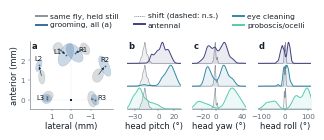

canvas 80.00 x 33.00 mm  = 25 mm panel block + 8 mm legend strip above it
mako: antennal=#413f80  eye cleaning=#3488a6  proboscis/ocelli=#55caad  |  grooming pooled=#366ca0
omitted from the distributions: leg rubbing (4,091 fr), unclassified (1,416 fr)

class                pitch Δ        p    yaw Δ        p   roll Δ        p   vs this fly's own rest
leg rubbing             +8.6   0.0000      +4.2   0.0001      +0.7   0.4429
antennal               +16.5   0.0000      +7.8   0.1719     +10.9   0.3920
eye cleaning           +26.8   0.0053     +10.7   0.5341      +5.2   0.4464
proboscis/ocelli        -0.2   0.8557     +23.3   0.0448     +42.4   0.0448

  Reference = this fly's own quiescent runs: pitch -17.4°, yaw -1.1°, roll +2.3°. It is not an unusual fly -- those sit
  2.7°/0.9°/2.7° from the other 44 flies (p = .08 / .05 / .05).

  POSITIVE pitch = NOSE DOWN, checked against z(Antenna_Base) - z(eye midpoint)
  (r = -0.979). Do not read the sign off the formula. Frame-level pitch media

In [ ]:
#  FIGURE: grooming by class vs. same held still 
# 
# HOW THE HEAD ANGLES ARE DEFINED:
#  an orthonormal head frame (Antenna_Base + EyeL + EyeR) expressed in the
#  THORAX frame, decomposed as pitch = -asin(hx.z_body), yaw = atan2(hx.y_body, hx.x_body), roll = atan2(hy.z_body, hz.z_body).
# The 50-node skeleton has NO left/right antenna base and NO neck keypoint: the lateral axis here is EyeR -> EyeL and
# pitch runs eye-midpoint -> Antenna_Base. Body-relative rather than global is deliberate
# No resting angle is subtracted, which is why the immobile fly sits at pitch -14 deg.
##

MM = 1 / 25.4
W_MM, H_PANEL_MM, H_LEG_MM = 80.0, 25.0, 8.0      # <- the specified panel size
H_MM = H_PANEL_MM + H_LEG_MM
FS, FS_TICK, FS_LEG, FS_SMALL = 6.0, 5.2, 5.4, 5.0
LW_AX, LW_KDE, LW_ELL = 0.4, 0.7, 0.4
A_REF, A_CLS = 0.14, 0.10          # halved: only grey-vs-class overlaps now

_MAKO = colormaps['mako']
PANEL_CLASSES = ['antennal', 'eye cleaning', 'proboscis/ocelli']
PANEL_COLOR = {'antennal':         mpl.colors.to_hex(_MAKO(0.30)),
               'eye cleaning':     mpl.colors.to_hex(_MAKO(0.55)),
               'proboscis/ocelli': mpl.colors.to_hex(_MAKO(0.78))}
C_GROOM = mpl.colors.to_hex(_MAKO(0.45))          # grooming pooled, panel a
C_REF   = '#8A949C'                               # the walking fly held still
_INK, _MUTED, _GREY = '#16202A', '#5C6B78', '#E7EBEF'

# WITHIN-ANIMAL COMPARISON. The reference is this same fly's own quiescent runs, not the
# 45-fly standing pool: with n = 1 grooming fly, a cross-fly comparison cannot separate
# "grooming" from "this individual". Swap in `stand_feat` for the cross-fly version.
_G = groom_feat
_S = stand_feat[stand_feat.fly == GROOM_FLY]
print(f'reference: {GROOM_FLY} -- {len(_S):,} frames in {_S.unit.nunique()} quiescent runs')

# SIX comparisons, one per leg -- matching the six arrows drawn. Each is ONE BIVARIATE
# test on (anterior, lateral). Correcting over 18 leg x axis tests
# would answer a different question ("which axis of which leg moved") and cost power.
# Unit = one grooming bout / one quiescent run. NEVER a frame: 16,072 grooming frames from
# one fly would pseudoreplicate ~10^4x and hand back p ~ 0 for everything.
from scipy.stats import mannwhitneyu

N_PERM = 20000
_rng = np.random.default_rng(0)        # fixed seed so the p-values reproduce exactly


def _holm(p):
    p = np.asarray(p); o = np.argsort(p); n = len(p); adj = np.empty(n); run = 0.
    for i, k in enumerate(o):
        run = max(run, (n - i) * p[k]); adj[k] = min(run, 1.)
    return adj


def _hotelling(X, Y):
    """Two-sample Hotelling T^2 on 2-D data."""
    n1, n2 = len(X), len(Y)
    d = X.mean(0) - Y.mean(0)
    Sp = ((n1 - 1) * np.cov(X, rowvar=False)
          + (n2 - 1) * np.cov(Y, rowvar=False)) / (n1 + n2 - 2)
    return (n1 * n2) / (n1 + n2) * d @ np.linalg.solve(Sp, d)


def _perm_p(X, Y, nperm=N_PERM):
    obs = _hotelling(X, Y); Z = np.vstack([X, Y]); n1 = len(X); cnt = 1
    for _ in range(nperm):
        i = _rng.permutation(len(Z))
        if _hotelling(Z[i[:n1]], Z[i[n1:]]) >= obs:
            cnt += 1
    return obs, cnt / (nperm + 1)


_praw, _shift = [], {}
for _lg in LEGS_6:
    _g = _G.groupby('unit')[[f'{_lg}_x', f'{_lg}_y']].median().dropna().values
    _s = _S.groupby('unit')[[f'{_lg}_x', f'{_lg}_y']].median().dropna().values
    _t2, _p = _perm_p(_g, _s)
    _praw.append(_p)
    _shift[_lg] = np.hypot(*(_g.mean(0) - _s.mean(0)))
SIG = dict(zip(LEGS_6, _holm(_praw)))
print(f'6 bivariate XY tests (Hotelling T2, {N_PERM:,} permutations), Holm over 6; '
      f'unit = bout vs run')
for _lg in LEGS_6:
    _m = ('***' if SIG[_lg] < .001 else '**' if SIG[_lg] < .01
          else '*' if SIG[_lg] < .05 else 'n.s.')
    print(f'   {LEG_LAB[_lg]:>3}  XY shift {_shift[_lg]:.2f} mm   '
          f'p_holm {SIG[_lg]:.4f}  {_m}')


def _eparams(x, y):
    """Median centre, 50%-coverage ellipse axes/angle, and bounding half-extents."""
    d = pd.concat([x, y], axis=1).dropna()
    xv, yv = d.iloc[:, 0].values, d.iloc[:, 1].values
    w, v = np.linalg.eigh(np.cov(xv, yv))
    a, b = 1.177 * np.sqrt(max(w[-1], 0)), 1.177 * np.sqrt(max(w[0], 0))
    th = np.arctan2(v[1, -1], v[0, -1])
    return (np.median(xv), np.median(yv), 2 * a, 2 * b, np.degrees(th),
            np.hypot(a * np.cos(th), b * np.sin(th)),
            np.hypot(a * np.sin(th), b * np.cos(th)))


_EP = {}
for _lg in LEGS_6:
    _EP[_lg, 'ref'] = _eparams(_S[f'{_lg}_y'], _S[f'{_lg}_x'])
    _EP[_lg, 'gr'] = _eparams(_G[f'{_lg}_y'], _G[f'{_lg}_x'])

# Front-leg medians are only ~0.5 mm apart, so those labels go OUTBOARD. The mid legs are
# the widest points on the plot (L2 sits 1.87 mm out vs R2 at 1.10), so theirs go ABOVE --
# outboard would run them off the axis.
_LOFF = {'T1L': (+.42, +.16), 'T1R': (-.42, +.16), 'T2L': (0, +.34), 'T2R': (0, +.34),
         'T3L': (+.34, +.10), 'T3R': (-.34, +.10)}

# Panel a limits come from the real ellipse extents, not hand-set numbers.
_PAD = .10
_xmax = max(max(abs(p[0]) + p[5] for p in _EP.values()),
            max(abs(_EP[l, 'gr'][0] + _LOFF[l][0]) + .16 for l in LEGS_6))
_ylo = min(p[1] - p[6] for p in _EP.values())
_yhi = max(max(p[1] + p[6] for p in _EP.values()),
           max(_EP[l, 'gr'][1] + _LOFF[l][1] + .10 for l in LEGS_6))
_XL, _YL = _xmax + _PAD, (_ylo - _PAD, _yhi + _PAD)

_ML, _MR, _AX_B, _AX_T = 7.4, 1.0, 6.9, 24.3      # margins in mm inside the 25 mm block
_AX_H = _AX_T - _AX_B
_A_W = _AX_H * (2 * _XL) / (_YL[1] - _YL[0])      # equal aspect -> width follows the data
_G1, _GK = 3.6, 3.0
_K_W = (W_MM - _ML - _A_W - _G1 - 2 * _GK - _MR) / 3
assert _K_W > 10, f'KDE panels too narrow: {_K_W:.1f} mm'
print(f'panel a {_A_W:.2f} x {_AX_H:.2f} mm | each KDE panel {_K_W:.2f} x {_AX_H:.2f} mm')

with plt.rc_context({'font.family': 'DejaVu Sans', 'font.size': FS,
                     'axes.edgecolor': _MUTED, 'axes.linewidth': LW_AX,
                     'text.color': _INK, 'axes.labelcolor': _INK, 'axes.labelsize': FS,
                     'xtick.labelsize': FS_TICK, 'ytick.labelsize': FS_TICK,
                     'xtick.color': _MUTED, 'ytick.color': _MUTED,
                     'xtick.major.width': .35, 'ytick.major.width': .35,
                     'xtick.major.size': 1.5, 'ytick.major.size': 1.5,
                     'xtick.major.pad': 1.6, 'ytick.major.pad': 1.6,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'svg.fonttype': 'none', 'pdf.fonttype': 42}):
    fig = plt.figure(figsize=(W_MM * MM, H_MM * MM))
    _rect = lambda x, w: [x / W_MM, _AX_B / H_MM, w / W_MM, _AX_H / H_MM]

    # ---- a: support base --------------------------------------------------
    ax = fig.add_axes(_rect(_ML, _A_W))
    for _lg in LEGS_6:
        for _key, _c, _al, _z in (('ref', C_REF, .32, 2), ('gr', C_GROOM, .26, 3)):
            _mx, _my, _w, _h, _th, _, _ = _EP[_lg, _key]
            ax.add_patch(Ellipse((_mx, _my), _w, _h, angle=_th, facecolor=_c, alpha=_al,
                                 edgecolor=_c, lw=LW_ELL, zorder=_z))
        _sx, _sy = _EP[_lg, 'ref'][:2]
        _gx, _gy = _EP[_lg, 'gr'][:2]
        _ok = SIG[_lg] < .05                      # dashed = no axis survives correction
        ax.annotate('', xy=(_gx, _gy), xytext=(_sx, _sy), zorder=5,
                    arrowprops=dict(arrowstyle='-|>', color=_INK if _ok else _MUTED,
                                    lw=.4, shrinkA=1, shrinkB=1, mutation_scale=3.2,
                                    linestyle='-' if _ok else (0, (1.4, 1.2))))
        ax.plot([_gx], [_gy], 'o', ms=1.3, color=C_GROOM, zorder=6, mew=0)
        _dx, _dy = _LOFF[_lg]
        ax.text(_gx + _dx, _gy + _dy, LEG_LAB[_lg], ha='center', va='center',
                fontsize=FS_SMALL, color=_INK, zorder=7)
    ax.plot([0], [0], 's', ms=2.0, color=_INK, zorder=6, mew=0)
    ax.axvline(0, color=_GREY, lw=.35, zorder=0)
    ax.axhline(0, color=_GREY, lw=.35, zorder=0)
    ax.set_xlabel('lateral (mm)', labelpad=1.2)
    ax.set_ylabel('anterior (mm)', labelpad=1.2)
    ax.set_xlim(_XL, -_XL); ax.set_ylim(*_YL)
    ax.set_xticks([1, 0, -1]); ax.set_yticks([0, 1, 2])   # 3 would sit outside ylim
    ax.set_aspect('equal')
    ax.text(.02, .99, 'a', transform=ax.transAxes, fontsize=FS, fontweight='bold',
            va='top', ha='left', color=_INK)

    # ---- b/c/d: head-angle KDEs -------------------------------------------
    _SPEC = [('head_pitch', 'head pitch (°)', (-40, 28), [-30, 0, 20]),
             ('head_yaw',   'head yaw (°)',   (-35, 45), [-20, 0, 40]),
             ('head_roll',  'head roll (°)', (-115, 115), [-100, 0, 100])]
    _x0 = _ML + _A_W + _G1
    for _j, (_col, _lab, _rng, _ticks) in enumerate(_SPEC):
        ax = fig.add_axes(_rect(_x0 + _j * (_K_W + _GK), _K_W))
        # RIDGELINE, one row per class. Four filled curves stacked on a shared baseline
        # were unreadable however low the alpha went, because the problem is occlusion,
        # not opacity. Rows remove class-class overlap entirely; the grey reference is
        # REPEATED in every row so each class is still read directly against rest.
        _xs = np.linspace(*_rng, 500)
        _ref = gaussian_kde(_S[_col].dropna())(_xs)
        _ref = _ref / _ref.max()
        _n = len(PANEL_CLASSES)
        _H = 1.0 / _n
        for _i, _c in enumerate(PANEL_CLASSES):
            _base = (_n - 1 - _i) * _H                    # first class on top
            _k = gaussian_kde(_G.loc[_G.behaviour == _c, _col].dropna())(_xs)
            _k = _k / _k.max()
            ax.fill_between(_xs, _base, _base + _H * .92 * _ref, color=C_REF,
                            alpha=A_REF, lw=0, zorder=2)
            ax.plot(_xs, _base + _H * .92 * _ref, color=C_REF, lw=.45, zorder=3)
            ax.fill_between(_xs, _base, _base + _H * .92 * _k, color=PANEL_COLOR[_c],
                            alpha=A_CLS, lw=0, zorder=4)
            ax.plot(_xs, _base + _H * .92 * _k, color=PANEL_COLOR[_c], lw=LW_KDE,
                    zorder=5)
            ax.axhline(_base, color=_GREY, lw=.3, zorder=1)
        ax.set_xlim(*_rng); ax.set_ylim(0, 1.0)
        ax.set_xticks(_ticks); ax.set_yticks([])
        for _sp in ('left', 'top', 'right'):
            ax.spines[_sp].set_visible(False)
        ax.set_xlabel(_lab, labelpad=1.2)
        ax.text(.02, .99, 'bcd'[_j], transform=ax.transAxes, fontsize=FS,
                fontweight='bold', va='top', ha='left', color=_INK)

    # ---- legend, hovering above the 25 mm rectangle -----------------------
    _L = lambda c, t: Line2D([], [], color=c, lw=1.4, label=t)
    _h = [_L(C_REF, 'same fly, held still'), _L(C_GROOM, 'grooming, all (a)'),
          Line2D([], [], color=_MUTED, lw=.5, ls=(0, (1.4, 1.2)),
                 label='shift (dashed: n.s.)'),
          _L(PANEL_COLOR['antennal'], 'antennal'),
          _L(PANEL_COLOR['eye cleaning'], 'eye cleaning'),
          _L(PANEL_COLOR['proboscis/ocelli'], 'proboscis/ocelli')]
    _leg = fig.legend(handles=_h, loc='lower left', ncol=3, frameon=False,
                      fontsize=FS_LEG, handlelength=1.4, handletextpad=.45,
                      columnspacing=.9, labelspacing=.28, mode='expand',
                      bbox_to_anchor=(_ML / W_MM, (H_PANEL_MM + 0.6) / H_MM,
                                      1 - (_ML + _MR) / W_MM, (H_LEG_MM - 1.0) / H_MM))
    for _t in _leg.get_texts():
        _t.set_color(_INK)

    for _ext in ('png', 'svg', 'pdf'):                # NO bbox_inches -- size is exact
        fig.savefig(OUTPUT_DIR / f'g4_groom_80mm.{_ext}',
                    dpi=1200 if _ext == 'png' else None)
    plt.show()

_w, _hh = fig.get_size_inches()
print(f'canvas {_w / MM:.2f} x {_hh / MM:.2f} mm  '
      f'= {H_PANEL_MM:.0f} mm panel block + {H_LEG_MM:.0f} mm legend strip above it')
print(f'mako: ' + '  '.join(f'{c}={PANEL_COLOR[c]}' for c in PANEL_CLASSES)
      + f'  |  grooming pooled={C_GROOM}')
print(f'omitted from the distributions: leg rubbing '
      f'({(_G.behaviour == "leg rubbing").sum():,} fr), unclassified '
      f'({(_G.behaviour == "unclassified").sum():,} fr)')

# ---- the numbers behind the figure, tested WITHIN the animal ---------------
print(f'\n{"class":<18}{"pitch Δ":>10}{"p":>9}{"yaw Δ":>9}{"p":>9}{"roll Δ":>9}{"p":>9}'
      f"   vs this fly's own rest")
for _cl in ['leg rubbing'] + PANEL_CLASSES:
    _g = _G[_G.behaviour == _cl]
    _row = f'{_cl:<18}'
    for _k in ('head_pitch', 'head_yaw', 'head_roll'):
        _a = _g.groupby('unit')[_k].median().dropna()
        _b = _S.groupby('unit')[_k].median().dropna()
        if len(_a) < 4:
            _row += f'{"--":>10}{"--":>9}'
            continue
        _row += f'{_a.median() - _b.median():>+10.1f}{mannwhitneyu(_a, _b).pvalue:>9.4f}'
    print(_row)
print(f"\n  Reference = this fly's own quiescent runs: pitch "
      f'{_S.head_pitch.median():+.1f}°, yaw {_S.head_yaw.median():+.1f}°, '
      f'roll {_S.head_roll.median():+.1f}°. It is not an unusual fly -- those sit')
print('  2.7°/0.9°/2.7° from the other 44 flies (p = .08 / .05 / .05).')
